# Final Project - STA4724

### How well can a set of water quality predictors predict changes in dissolved oxygen levels for the Back Bay National Wildlife Refuge?

##### Naziat Chowdhury, Caitlin Box, Sameer Bashir, Mustaeen Ahmed

#### Initialization and Preprocessing

In [370]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import statsmodels.formula.api as smf
from scipy.stats import shapiro

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import statsmodels.api as sm

import itertools

In [371]:
df = pd.read_csv("back-bay.csv")
df = df.drop([
    "Unit_Id",
    "Read_Date",
    "Time (24:00)",
    "Field_Tech",
    "DateVerified",
    "WhoVerified",
    "Air Temp (?F)",
    "Air Temp-Celsius",
    "Year"
], axis=1)

df = df.rename(columns={
    "Salinity (ppt)" : "Salinity",
    "Dissolved Oxygen (mg/L)" : "Dissolved_Oxygen",
    "pH (standard units)" : "pH",
    "Secchi Depth (m)" : "Secchi_Depth",
    "Water Depth (m)" : "Water_Depth",
    "Water Temp (?C)" : "Water_Temp",
    "AirTemp (C)" : "Air_Temp",
})

print(df.shape)
df.head()

(2371, 8)


,Site_Id,Salinity,Dissolved_Oxygen,pH,Secchi_Depth,Water_Depth,Water_Temp,Air_Temp
0,Bay,1.3,11.7,7.3,0.40,0.40,5.9,8.0
1,Bay,1.5,12.0,7.4,0.20,0.35,3.0,2.6
2,Bay,1.0,10.5,7.2,0.25,0.60,5.9,7.6
3,Bay,1.0,10.1,7.4,0.35,0.50,10.0,2.7
4,Bay,1.0,12.6,7.2,0.20,0.40,1.6,0.0


In [372]:
df["Site_Id"] = df["Site_Id"].astype("category")

df = df[df["Water_Temp"] <= 35]
df = df[df["Air_Temp"] <= 35]
df = df[df["Water_Temp"] > 0]
df = df[df["pH"] > 0.3]
df = df[df["Dissolved_Oxygen"] > 2]
df = df[df["Salinity"] < 9]

df = df.dropna() # drop all data points with missing values

df.shape

(1286, 8)

In [373]:
df.describe(include="all")

# summary of data

,Site_Id,Salinity,Dissolved_Oxygen,pH,Secchi_Depth,Water_Depth,Water_Temp,Air_Temp
count,1286,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000,1286.000000
unique,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Bay,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.897970,6.826726,7.209603,0.498628,0.750556,17.753118,15.752663
std,NaN,1.321837,2.427621,0.780232,0.480942,0.579570,7.860031,10.049011
min,NaN,0.000000,2.200000,4.800000,0.000000,0.010000,1.000000,-17.777778
25%,NaN,0.000000,5.000000,6.500000,0.300000,0.450000,11.000000,8.888889
50%,NaN,0.000000,6.700000,7.000000,0.400000,0.680000,18.000000,16.666667
75%,NaN,1.500000,8.700000,7.500000,0.600000,0.900000,25.000000,23.888889


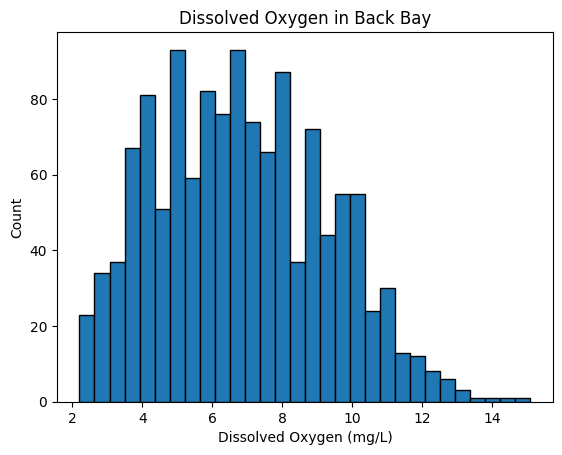

In [374]:
plt.figure()
plt.hist(df["Dissolved_Oxygen"], bins=30, edgecolor="k")
plt.xlabel("Dissolved Oxygen (mg/L)")
plt.ylabel("Count")
plt.title("Dissolved Oxygen in Back Bay")
plt.show()

In [375]:
columns_numeric = [
    "Salinity", "Dissolved_Oxygen", "pH", "Secchi_Depth", "Water_Depth", "Water_Temp", "Air_Temp"
]

df[columns_numeric].corr()

# correlation matrix of numeric columns

,Salinity,Dissolved_Oxygen,pH,Secchi_Depth,Water_Depth,Water_Temp,Air_Temp
Salinity,1.000000,0.387853,0.329143,-0.151235,-0.068264,-0.000546,0.077619
Dissolved_Oxygen,0.387853,1.000000,0.087146,-0.067435,-0.019854,-0.542948,-0.330632
pH,0.329143,0.087146,1.000000,-0.118637,-0.133882,0.198845,0.170777
Secchi_Depth,-0.151235,-0.067435,-0.118637,1.000000,0.850850,0.018684,-0.018513
Water_Depth,-0.068264,-0.019854,-0.133882,0.850850,1.000000,0.070690,0.047586
Water_Temp,-0.000546,-0.542948,0.198845,0.018684,0.070690,1.000000,0.699924
Air_Temp,0.077619,-0.330632,0.170777,-0.018513,0.047586,0.699924,1.000000


In [376]:
train, test = train_test_split(df, test_size=0.3, random_state=1)

print(train.shape)
test.shape

(900, 8)


(386, 8)

In [377]:
log_water_formula = "Dissolved_Oxygen ~ Salinity + pH + np.log(Water_Temp) + C(Site_Id)" # log water
log_salinity_formula = "Dissolved_Oxygen ~ np.log(Salinity + 1) + pH + Water_Temp + C(Site_Id)" # as salinity is <1 in the dataset
temp_depth_interaction_formula = "Dissolved_Oxygen ~ Salinity + pH + Water_Temp * Water_Depth + Site_Id" # interaction term, water depth and water temp


log_water = smf.ols(formula=log_water_formula, data=train).fit()
log_salinity = smf.ols(formula=log_salinity_formula, data=train).fit()
temp_depth = smf.ols(formula=temp_depth_interaction_formula, data=train).fit()

In [378]:
# get residuals and fitted values

log_water_resid = log_water.resid
log_water_fitted = log_water.fittedvalues

log_salinity_resid = log_salinity.resid
log_salinity_fitted = log_salinity.fittedvalues

temp_depth_resid = temp_depth.resid
temp_depth_fitted = temp_depth.fittedvalues

In [379]:
# shapiro-wilk test, normality

log_water_W, log_water_p_value = shapiro(log_water_resid)
print("Log Water W = ", log_water_W)
print("Log Water p-value = ", log_water_p_value)

log_salinity_W, log_salinity_p_value = shapiro(log_salinity_resid)
print("\nLog Salinity W = ", log_salinity_W)
print("Log Salinity p-value = ", log_salinity_p_value)

temp_depth_W, temp_depth_p_value = shapiro(temp_depth_resid)
print("\nTemp x Depth W = ", temp_depth_W)
print("Temp x Depth p-value = ", temp_depth_p_value)

Log Water W =  0.9972296367656994
Log Water p-value =  0.12726081126111255

Log Salinity W =  0.995614344416566
Log Salinity p-value =  0.011540677255575981

Temp x Depth W =  0.9967399490489124
Temp x Depth p-value =  0.061686990698970816


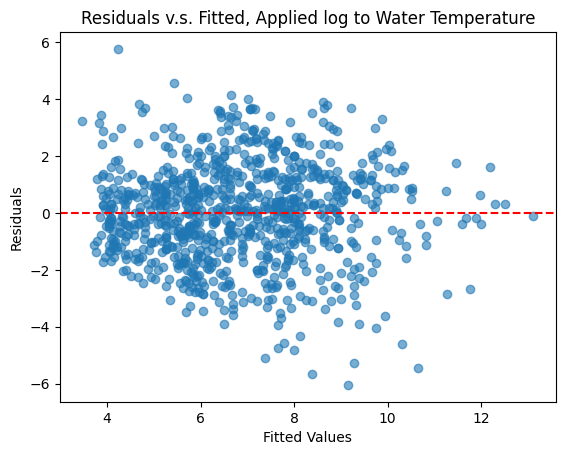

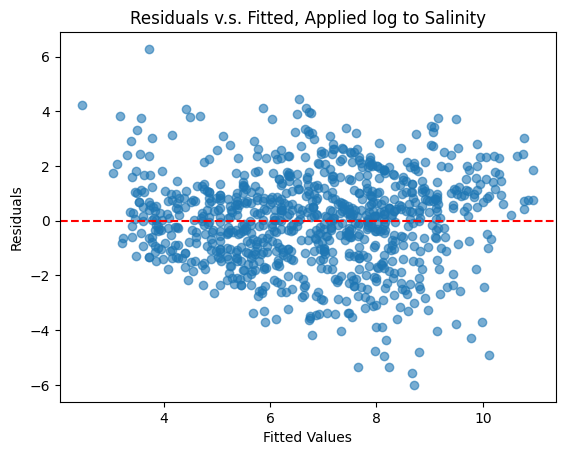

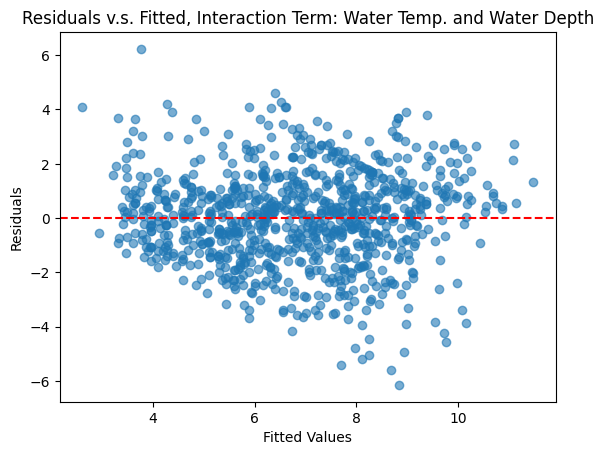

In [380]:
# residual vs fitted plots

plt.figure()
plt.scatter(log_water_fitted, log_water_resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals v.s. Fitted, Applied log to Water Temperature")
plt.show()

plt.figure()
plt.scatter(log_salinity_fitted, log_salinity_resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals v.s. Fitted, Applied log to Salinity")
plt.show()

plt.figure()
plt.scatter(temp_depth_fitted, temp_depth_resid, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals v.s. Fitted, Interaction Term: Water Temp. and Water Depth")
plt.show()


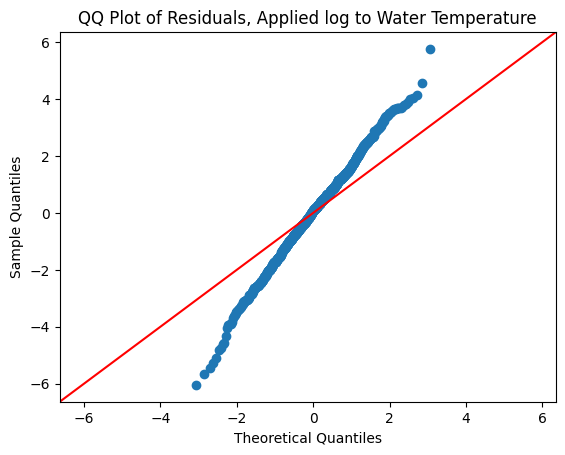

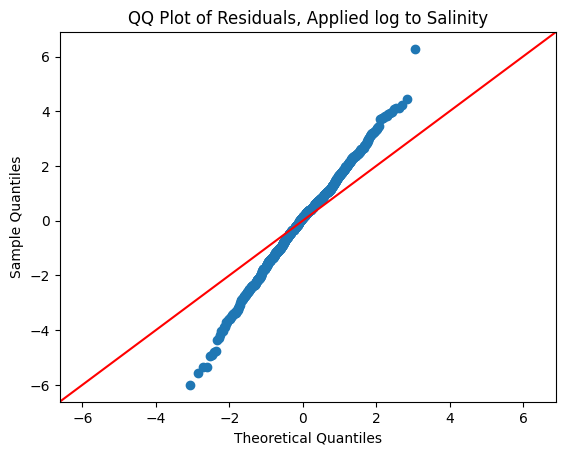

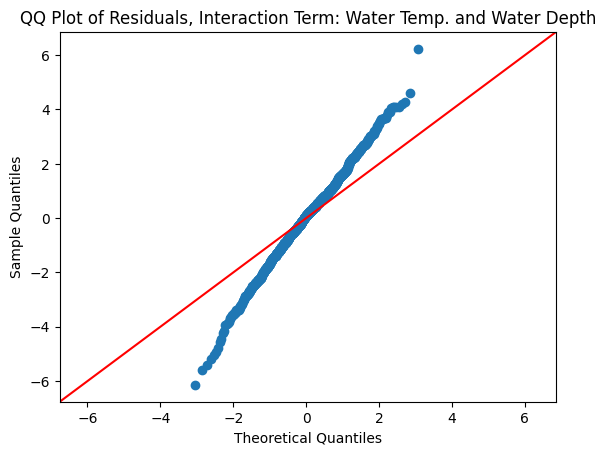

In [381]:
# qq plots of residuals

sm.qqplot(log_water_resid, line="45")
plt.title("QQ Plot of Residuals, Applied log to Water Temperature")
plt.show()

sm.qqplot(log_salinity_resid, line="45")
plt.title("QQ Plot of Residuals, Applied log to Salinity")
plt.show()

sm.qqplot(temp_depth_resid, line="45")
plt.title("QQ Plot of Residuals, Interaction Term: Water Temp. and Water Depth")
plt.show()

In [382]:
# mean absolute error

log_water_pred_train = log_water.predict(train)
log_water_pred_test = log_water.predict(test)

log_water_mae_train = mean_absolute_error(train["Dissolved_Oxygen"], log_water_pred_train)
log_water_mae_test = mean_absolute_error(test["Dissolved_Oxygen"], log_water_pred_test)

print("Log Water MAE Train:", log_water_mae_train)
print("Log Water MAE Test:", log_water_mae_test)

log_salinity_pred_train = log_salinity.predict(train)
log_salinity_pred_test = log_salinity.predict(test)

log_salinity_mae_train = mean_absolute_error(train["Dissolved_Oxygen"], log_salinity_pred_train)
log_salinity_mae_test = mean_absolute_error(test["Dissolved_Oxygen"], log_salinity_pred_test)

print("\nLog Salinity MAE Train:", log_salinity_mae_train)
print("Log Salinity MAE Test:", log_salinity_mae_test)

temp_depth_pred_train = temp_depth.predict(train)
temp_depth_pred_test = temp_depth.predict(test)

temp_depth_mae_train = mean_absolute_error(train["Dissolved_Oxygen"], temp_depth_pred_train)
temp_depth_mae_test = mean_absolute_error(test["Dissolved_Oxygen"], temp_depth_pred_test)

print("\nTemp x Depth MAE Train:", temp_depth_mae_train)
print("Temp x Depth MAE Test:", temp_depth_mae_test)

Log Water MAE Train: 1.3623702000043432
Log Water MAE Test: 1.3228028545462838

Log Salinity MAE Train: 1.3334465680981349
Log Salinity MAE Test: 1.282731501140564

Temp x Depth MAE Train: 1.334750141395791
Temp x Depth MAE Test: 1.2711110013726246


#### Among the three tested models, the `log_salinity` model gets the lowest MAE values, making it the best performing for predictive accuracy.